# General

## Setup

In [1]:
from manim import *
config.media_width = "75%"
config.verbosity = "WARNING"

In [32]:
%%manim -qh EndCard

class EndCard(Scene):
    def construct(self):
        ppu = config.pixel_width / config.frame_width
        
        circle = Circle(radius=298/(2*ppu), color=WHITE, fill_opacity=1)
        circle.move_to(LEFT*4)
        
        rectangle = Rectangle(width=613/ppu, height=343/ppu)
        #rectangle = Rectangle(width=861/ppu, height=482/ppu)
        rectangle.move_to(RIGHT*3 + UP*1.5)
        #rectangle.set_color_by_gradient(BLUE, RED)
        rectangle2 = Rectangle(width=613/ppu, height=343/ppu)
        rectangle2.move_to(RIGHT*3 + DOWN*1.5)
        
        text = Text("Thanks for \nwatching")
        text.move_to(UP*2 + LEFT*4)
        
        self.play(FadeIn(circle), Create(rectangle), Create(rectangle2))
        self.wait(40)
        

Manim Community v0.18.1

## Plotting

### Plotting a continuous function

In [1]:
%%manim -qm Graph

class Graph(Scene):
    def construct(self):
        f1 = lambda x: 0.1*(x+2)*(x-3)*(x-6)

        axes = Axes(
            x_range=[-10, 10.3, 1],
            y_range=[-5, 5, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-10, 10.01, 2),
                "numbers_with_elongated_ticks": np.arange(-10, 10.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-4, 4.01, 1),
            },
            tips=False,
        )
        axes_labels = axes.get_axis_labels()
        f1_graph = axes.plot(f1, color=BLUE)
        
        f1_label = axes.get_graph_label(
            f1_graph, "f(x) = \\frac{(x+2)(x-3)(x-6)}{10}", x_val=-10, direction=UP*1000000
        )

        plot = VGroup(axes, f1_graph)
        labels = VGroup(axes_labels, f1_label)

        self.add(plot, labels)

UsageError: Cell magic `%%manim` not found.


In [6]:
%%manim -qm RiemannRectangles

class RiemannRectangles(Scene):
    def construct(self):
        f1 = lambda x: 0.1*(x+2)*(x-3)*(x-6)
        x_range = [-2,3]

        axes = Axes(
            x_range=[-8, 8.3, 1],
            y_range=[-3, 5, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-8, 8.01, 2),
                "numbers_with_elongated_ticks": np.arange(-10, 10.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-2, 4.01, 1),
            },
            tips=False,
        )
        axes_labels = axes.get_axis_labels()
        f1_graph = axes.plot(f1, color=BLUE)
        
        f1_label = axes.get_graph_label(
            f1_graph, "f(x) = \\frac{(x+2)(x-3)(x-6)}{10}", x_val=-10, direction=UP*1000000
        )

        plot = VGroup(axes, f1_graph)
        labels = VGroup(axes_labels, f1_label)

        self.add(plot, labels)
        self.wait()

        riemann_rectangles = axes.get_riemann_rectangles(
            axes.plot(lambda x: 0),
            x_range = x_range,
            dx = 0.5,
            input_sample_type = "left"
        )
        self.add(riemann_rectangles)
        
        
        for i in range(0, 4):
            new = axes.get_riemann_rectangles(
                f1_graph,
                x_range=[-2,3],
                dx=0.5 * 2 ** (-i),
                input_sample_type="left"
            )
            self.play(ReplacementTransform(riemann_rectangles, new))
            riemann_rectangles = new
            if (i == 0):
                self.wait()

        self.wait()

Manim Community v0.18.1

### Plotting a discontinuous function

Manim Community v0.18.1

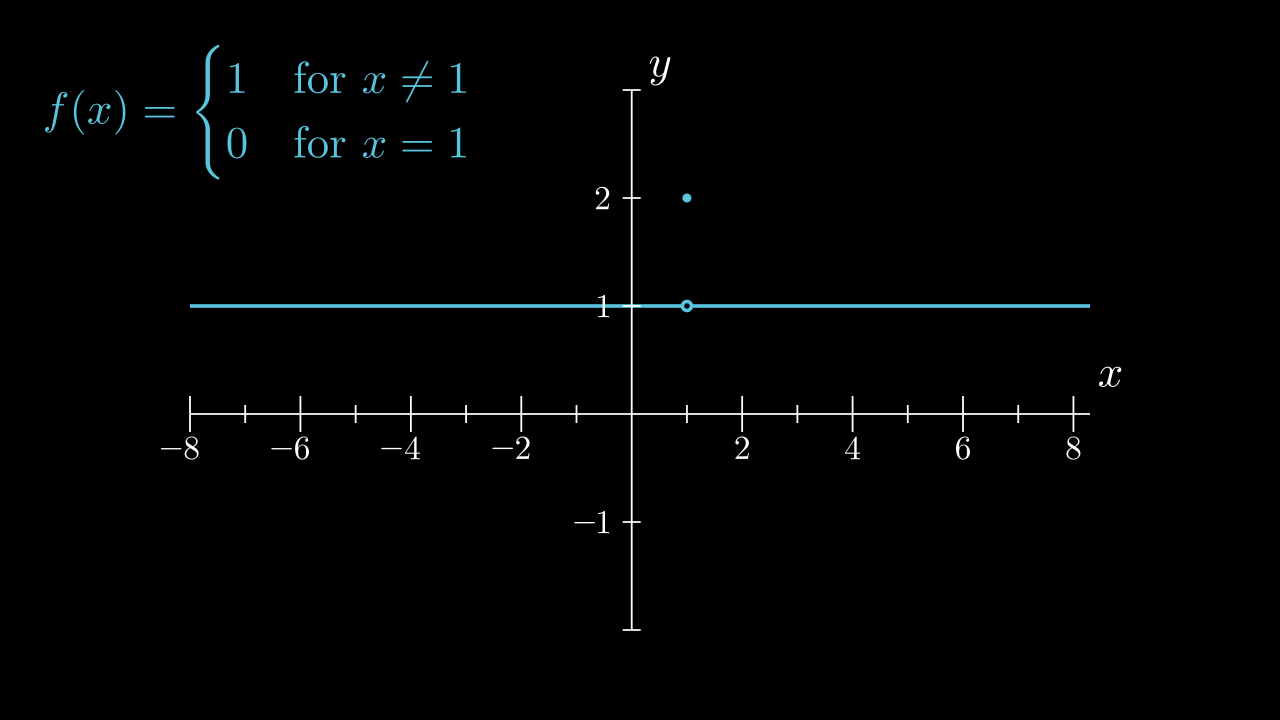

In [14]:
%%manim -qm DiscontinuousFunction

class DiscontinuousFunction(Scene):
    def construct(self):
        def getGraphPlot(axes, f1, discontinuities, values, dt):
            graph = VGroup()
            graph.add(axes.plot(f1, discontinuities = discontinuities, dt=dt, color=BLUE))
            for d in range(len(discontinuities)):
                graph.add(Dot(point=axes.coords_to_point(discontinuities[d], f1(discontinuities[d])), radius = 0.05, color=BLUE))
                graph.add(Circle(radius=0.05, color=BLUE).move_to(axes.coords_to_point(discontinuities[d], values[d])))
            return graph
        
        def f1(x):
            if (x == 1):
                return 2
            else:
                return 1

        axes = Axes(
            x_range=[-8, 8.3, 1],
            y_range=[-2, 3, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-8, 8.01, 2),
                "numbers_with_elongated_ticks": np.arange(-8, 8.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-1, 2.01, 1),
            },
            tips=False,
        )
        axes_labels = axes.get_axis_labels()
        f1_graph = axes.plot(f1, discontinuities = [1], dt=0.1, color=BLUE)
        discontinuity = Dot(point=axes.coords_to_point(1, 2), radius = 0.05, color=BLUE)
        circle1 = Circle(radius=0.05, color=BLUE).move_to(axes.coords_to_point(1, 1))
   
        graph_label = axes.get_graph_label(
            f1_graph, "f(x) = \\begin{cases}1 & \\text{for }x \\ne 1 \\\\ 0 & \\text{for } x = 1\\end{cases}", x_val=-10, direction=UP*1000000
        )

        graph_plot = getGraphPlot(axes, f1, discontinuities = [1], values = [1], dt = 0.1)
        
        #graph_plot = VGroup(f1_graph, discontinuity, circle1, f1_label)
        axes_plot = VGroup(axes, axes_labels)

        self.add(graph_plot, graph_label, axes_plot)

## Riemann rectangles

In [5]:
%%manim -qm RiemannRectangles

class RiemannRectangles(Scene):
    def construct(self):
        f1 = lambda x: 0.1*(x+2)*(x-3)*(x-6)
        x_range = [-2,3]

        axes = Axes(
            x_range=[-8, 8.3, 1],
            y_range=[-3, 5, 1],
            x_length=10,
            axis_config={"color": WHITE},
            x_axis_config={
                "numbers_to_include": np.arange(-8, 8.01, 2),
                "numbers_with_elongated_ticks": np.arange(-8, 8.01, 2),
            },
            y_axis_config={
                "numbers_to_include": np.arange(-2, 4.01, 1),
            },
            tips=False,
        )
        axes_labels = axes.get_axis_labels()
        f1_graph = axes.plot(f1, color=BLUE)
        
        f1_label = axes.get_graph_label(
            f1_graph, "f(x) = \\frac{(x+2)(x-3)(x-6)}{10}", x_val=-10, direction=UP*1000000
        )

        plot = VGroup(axes, f1_graph)
        labels = VGroup(axes_labels, f1_label)

        self.add(plot, labels)
        self.wait()

        riemann_rectangles = axes.get_riemann_rectangles(
            axes.plot(lambda x: 0),
            x_range = x_range,
            dx = 0.5,
            input_sample_type = "left"
        )
        self.add(riemann_rectangles)
        
        
        for i in range(0, 4):
            new = axes.get_riemann_rectangles(
                f1_graph,
                x_range=x_range,
                dx=0.5 * 2 ** (-i),
                input_sample_type="left"
            )
            self.play(ReplacementTransform(riemann_rectangles, new))
            riemann_rectangles = new
            if (i == 0):
                self.wait()

        self.wait()

Manim Community v0.18.1